Contornos restantes: 39


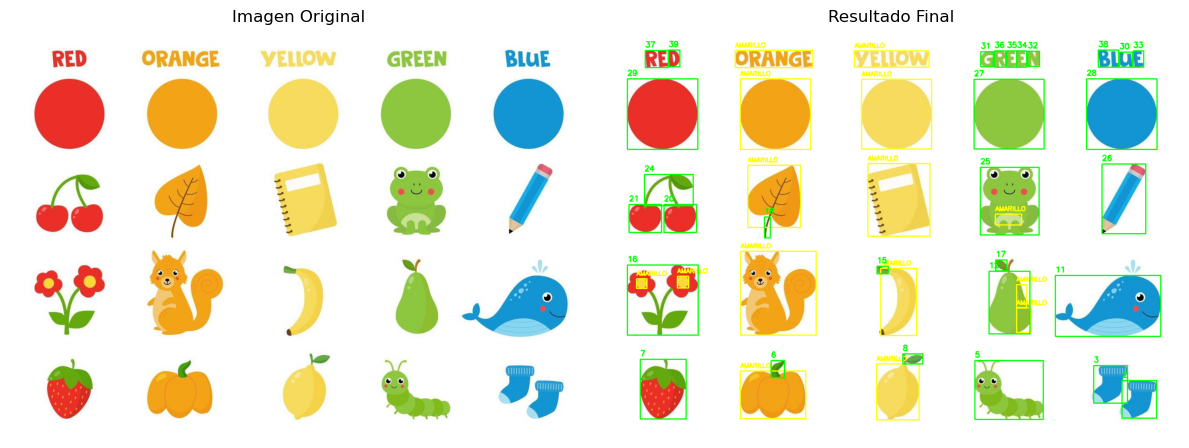

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# CARGAR IMAGEN
ruta_imagen = 'colores.jpg'
imagen = cv2.imread(ruta_imagen)

if imagen is None:
    raise FileNotFoundError("No fue posible abrir la imagen")

# COPIA PARA RESULTADOS
resultado = imagen.copy()

# CONVERSION A HSV
imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

# UMBRALES PARA COLOR AMARILLO
amarillo_min = np.array([18, 80, 80])
amarillo_max = np.array([40, 255, 255])

mascara_amarilla = cv2.inRange(imagen_hsv, amarillo_min, amarillo_max)

# FILTRADO MORFOLOGICO
elemento = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mascara_amarilla = cv2.morphologyEx(mascara_amarilla, cv2.MORPH_CLOSE, elemento)
mascara_amarilla = cv2.morphologyEx(mascara_amarilla, cv2.MORPH_OPEN, elemento)

# BUSQUEDA DE CONTORNOS AMARILLOS
contornos_amarillos, _ = cv2.findContours(
    mascara_amarilla,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

area_minima = 200
cantidad_amarillos = 0

for figura in contornos_amarillos:
    if cv2.contourArea(figura) < area_minima:
        continue

    px, py, ancho, alto = cv2.boundingRect(figura)

    cv2.rectangle(resultado, (px, py), (px + ancho, py + alto), (0, 255, 255), 2)
    cv2.putText(
        resultado,
        "AMARILLO",
        (px, py - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 255),
        2
    )

    cantidad_amarillos += 1


# PROCESAMIENTO EN ESCALA DE GRISES
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
suavizada = cv2.GaussianBlur(gris, (5, 5), 0)

_, imagen_binaria = cv2.threshold(
    suavizada,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# VERIFICACION DE INVERSION
cont_prueba, _ = cv2.findContours(
    imagen_binaria,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

alto_img, ancho_img = imagen_binaria.shape
superficie_total = alto_img * ancho_img

if len(cont_prueba) == 1:
    if cv2.contourArea(cont_prueba[0]) > superficie_total * 0.9:
        imagen_binaria = cv2.bitwise_not(imagen_binaria)

# ELIMINAR REGIONES AMARILLAS
imagen_binaria[mascara_amarilla == 255] = 0

# LIMPIEZA DE RUIDO
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
imagen_binaria = cv2.morphologyEx(imagen_binaria, cv2.MORPH_CLOSE, kernel_rect)
imagen_binaria = cv2.morphologyEx(imagen_binaria, cv2.MORPH_OPEN, kernel_rect)

# CONTORNOS RESTANTES
contornos_restantes, _ = cv2.findContours(
    imagen_binaria,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contornos restantes:", len(contornos_restantes))

contador = 0

for numero, figura in enumerate(contornos_restantes, start=1):

    if cv2.contourArea(figura) < area_minima:
        continue

    x, y, w, h = cv2.boundingRect(figura)

    cv2.rectangle(resultado, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(
        resultado,
        str(numero),
        (x, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

    contador += 1


# MOSTRAR RESULTADOS
plt.figure(figsize=(12, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Resultado Final")
plt.axis("off")

plt.tight_layout()
plt.show()